# Étude des Residual Neural Networks

Importation des données CIFAR-10

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms


transform = transforms.Compose( # Compose permet de définir la pipeline de traitement de l'image
    [transforms.ToTensor(), # on transforme les images (pixels entre 0 et 255) en tenseur (entre 0 et 1)
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) # on normalize moyenne et écart-type


trainset = torchvision.datasets.CIFAR10(root='./data', train=True, # on récupère le jeu de données train
                                        download=True, transform=transform) # on l'associe au pipeline transform
testset = torchvision.datasets.CIFAR10(root='./data', train=False, # on récupère le jeu de données test
                                       download=True, transform=transform)

# Créer des DataLoaders pour l'entraînement et le test
# batch_size définit le nombre d'échantillons traités par lot
# shuffle=True pour l'entraînement permet de mélanger les données à chaque époque
# num_workers > 0 peut accélérer le chargement des données en utilisant des processus parallèles
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)


testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

# Classes CIFAR-10
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Nombre d'échantillons d'entraînement: {len(trainset)}")
print(f"Nombre d'échantillons de test: {len(testset)}")
print(f"Taille d'un lot d'entraînement: {trainloader.batch_size}")
print(f"Taille d'un lot de test: {testloader.batch_size}")

# Afficher la forme d'un lot d'images et d'étiquettes
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(f"Forme d'un lot d'images: {images.shape}")
print(f"Forme d'un lot d'étiquettes: {labels.shape}")


100%|██████████| 170M/170M [00:06<00:00, 25.8MB/s]


Nombre d'échantillons d'entraînement: 50000
Nombre d'échantillons de test: 10000
Taille d'un lot d'entraînement: 4
Taille d'un lot de test: 4
Forme d'un lot d'images: torch.Size([4, 3, 32, 32])
Forme d'un lot d'étiquettes: torch.Size([4])


Visualisation de quelques données CIFAR-10 avec leurs étiquettes

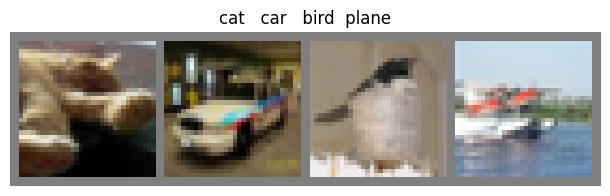

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Fonction pour afficher une image
def imshow(img):
    img = img / 2 + 0.5  # dénormaliser
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off') # masquer les axes

# Obtenir des images d'entraînement aléatoires
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Afficher les images dans une grille
plt.figure(figsize=(8, 2))
imshow(torchvision.utils.make_grid(images))
plt.title(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
plt.show()

Création d'un CNN de 5 couches

In [3]:

import torch.nn as nn
import torch.nn.functional as F  # Pour les fonctions d'activation comme relu

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolution 1: 3 in -> 6 out, kernel 5
        self.conv1 = nn.Conv2d(3, 6, 5)
        # Pooling: 2x2
        self.pool = nn.MaxPool2d(2, 2)
        # Convolution 2: 6 in -> 16 out, kernel 5
        self.conv2 = nn.Conv2d(6, 16, 5)

        # Couches linéaires
        # 16 canaux * 5 * 5 image = 400
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10) # 10 classes en sortie

    def forward(self, x):
        # Bloc 1
        x = self.pool(F.relu(self.conv1(x)))
        # Bloc 2
        x = self.pool(F.relu(self.conv2(x)))

        # Aplatissement (Flatten)
        x = torch.flatten(x, 1)

        # Classification
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # Pas d'activation ici
        return x

# Création du réseau
net = SimpleCNN()
print(net)


optimizer = torch.optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

SimpleCNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


Training du CNN

In [4]:
for epoch in range(2):  # On va faire 2 tours complets du dataset
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # 1. Récupérer les données
        inputs, labels = data

        # 2. Remise à zéro des gradients (Indispensable en PyTorch !)
        optimizer.zero_grad()

        # 3. Forward pass : Calculer les sorties du réseau en lui donnant 'inputs'
        outputs = net(inputs)

        # 4. Calcul de la perte : Comparer 'outputs' avec 'labels'
        loss = criterion(outputs, labels)

        # 5. Backward & Optimize
        loss.backward()
        optimizer.step()

        # Affichage pour suivre l'avancée
        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Entraînement terminé')

[1,  2000] loss: 2.230
[1,  4000] loss: 1.875
[1,  6000] loss: 1.664
[1,  8000] loss: 1.584
[1, 10000] loss: 1.517
[1, 12000] loss: 1.451
[2,  2000] loss: 1.389
[2,  4000] loss: 1.360
[2,  6000] loss: 1.325
[2,  8000] loss: 1.306
[2, 10000] loss: 1.288
[2, 12000] loss: 1.272
Entraînement terminé


Test du CNN

In [5]:
correct = 0
total = 0

# On désactive le calcul des gradients pour le test
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # 1. Demander au réseau de deviner
        outputs = net(images)

        # 2. Trouver la classe qui a le plus haut score
        _, predicted = torch.max(outputs, 1)

        # 3. Mettre à jour les compteurs total et correct
        total +=labels.size(0)
        correct += (predicted == labels).sum().item()

In [6]:
print(f'Précision sur le test: {100 * correct / total}%')

Précision sur le test: 55.99%


Création du ResNet

In [7]:
import torch.nn as nn
import torch.nn.functional as F

# définition d'un block Residual

class ResidualBlock(nn.Module):
	def __init__(self,in_channels,out_channels,stride=1):
		super().__init__() # on utilise les constructeurs de la classe mère

		self.conv1 = nn.Conv2d(
			in_channels= in_channels,
			out_channels=out_channels,
			kernel_size=3,
			stride=stride,
			padding=1,
			bias= False # le b de ax+b, ici ne sert à rien comme on fait un batch norm après, don cFalse pour éconimiser mémoire et calcul
		)
		self.bn1= nn.BatchNorm2d(out_channels) # recentrer les données (soustraire la moyenne)


		self.conv2 = nn.Conv2d(
				in_channels=out_channels,
				out_channels=out_channels,
				kernel_size=3,
				stride=1,
				padding=1,
				bias=False
			)
		self.bn2 = nn.BatchNorm2d(out_channels)

		# Maintenant on définit la shortcut connection
		self.shortcut = nn.Sequential() # conteneur

		# Si la taille de sortie est diff de celle d'entrée, on peut plus sommer x+F(x), donc on doit changer les dim
		if stride != 1 or in_channels != out_channels :
			self.shortcut = nn.Sequential(
				nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

	def forward(self, x):
		out = F.relu(self.bn1(self.conv1(x)))
		out = self.bn2(self.conv2(out))
		out += self.shortcut(x)
		out = F.relu(out)
		return out


In [8]:
# modèle complet du ResNet de 18 couches

class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.in_channels = 64 # standard historique défini par le papier ResNet

        # Partie initiale
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # Les 4 étages (Layers)
        # Layer 1 : 64 canaux, 2 blocs, stride 1 (on garde la taille 32x32)
        self.layer1 = self._make_layer(out_channels=64, num_blocks=2, stride=1)

        # Layer 2 : 128 canaux, 2 blocs, stride 2 (taille devient 16x16)
        self.layer2 = self._make_layer(out_channels=128, num_blocks=2, stride=2)

        # Layer 3 : 256 canaux, 2 blocs, stride 2 (taille devient 8x8)
        self.layer3 = self._make_layer(out_channels=256, num_blocks=2, stride=2)

        # Layer 4 : 512 canaux, 2 blocs, stride 2 (taille devient 4x4)
        self.layer4 = self._make_layer(out_channels=512, num_blocks=2, stride=2)

        # Classifieur final
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Moyenne globale 4x4 -> 1x1,
		# cette ligne permet de supprimer l'information spatiale (on se fiche de savoir si l'oreille du chat est en haut à gauche ou à droite) pour se concentrer sur la présence des caractéristiques. "Adaptive" signifie simplement que peu importe la taille de l'image qui arrive (4x4, 8x8...), il forcera la sortie à faire la taille demandée (1, 1).
        self.fc = nn.Linear(512, 10) # 512 entrées -> 10 classes, calcule du score pour les 10 classes en fonction des 512 caractéristiques

    # fonction usine qui permet de définir un residual block
    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out) # calcule un score pour chacune des 10 classes parmi les 512 caractéristiques
        return out



Entrainement du ResNet

In [9]:
for epoch in range(2):  # On boucle sur le jeu de données plusieurs fois
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        # 1. Remise à zéro
        optimizer.zero_grad()

        # 2. Forward + Backward + Optimize (Tes lignes)
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Affichage statistiques
        running_loss += loss.item()
        if i % 2000 == 1999:    # Tous les 2000 mini-batchs
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Entraînement terminé')

[1,  2000] loss: 1.187
[1,  4000] loss: 1.185
[1,  6000] loss: 1.176
[1,  8000] loss: 1.183
[1, 10000] loss: 1.154
[1, 12000] loss: 1.158
[2,  2000] loss: 1.069
[2,  4000] loss: 1.105
[2,  6000] loss: 1.097
[2,  8000] loss: 1.057
[2, 10000] loss: 1.070
[2, 12000] loss: 1.082
[3,  2000] loss: 0.976
[3,  4000] loss: 1.021
[3,  6000] loss: 1.029
[3,  8000] loss: 1.000
[3, 10000] loss: 1.017
[3, 12000] loss: 1.021
[4,  2000] loss: 0.940
[4,  4000] loss: 0.946
[4,  6000] loss: 0.965
[4,  8000] loss: 0.961
[4, 10000] loss: 0.955
[4, 12000] loss: 0.986
[5,  2000] loss: 0.873
[5,  4000] loss: 0.895
[5,  6000] loss: 0.932
[5,  8000] loss: 0.931
[5, 10000] loss: 0.927
[5, 12000] loss: 0.934
Entraînement terminé


Test du ResNet

In [10]:
correct = 0
total = 0

# On désactive le calcul des gradients pour le test
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # 1. Demander au réseau de deviner
        outputs = net(images)

        # 2. Trouver la classe qui a le plus haut score
        _, predicted = torch.max(outputs, 1)

        # 3. Mettre à jour les compteurs total et correct
        total +=labels.size(0)
        correct += (predicted == labels).sum().item()

In [11]:
print(f'Précision sur le test: {100 * correct / total}%')

Précision sur le test: 64.32%


Après avoir codé ce premier ResNet à la main, nous nous rendons compte que chaque layer doit être ajouté à la main. Afin de faire des modèles plus conséquents, nous devons modifier la class ResNet pour qu'elle soit dynamique et prenne un paramètre n en input définissant la taille du modèle tel que

taille = 6 x n + 2

# Etude ResNet sans Batch Normalization

In [13]:
import torch.nn as nn
import torch.nn.functional as F

# définition d'un block Residual

class ResidualBlock_no_bn(nn.Module):
	def __init__(self,in_channels,out_channels,stride=1):
		super().__init__() # on utilise les constructeurs de la classe mère

		self.conv1 = nn.Conv2d(
			in_channels= in_channels,
			out_channels=out_channels,
			kernel_size=3,
			stride=stride,
			padding=1,
			bias= False # le b de ax+b, ici ne sert à rien comme on fait un batch norm après, don cFalse pour éconimiser mémoire et calcul
		)
		#self.bn1= nn.BatchNorm2d(out_channels) # recentrer les données (soustraire la moyenne)


		self.conv2 = nn.Conv2d(
				in_channels=out_channels,
				out_channels=out_channels,
				kernel_size=3,
				stride=1,
				padding=1,
				bias=False
			)
		#self.bn2 = nn.BatchNorm2d(out_channels)

		# Maintenant on définit la shortcut connection
		self.shortcut = nn.Sequential() # conteneur

		# Si la taille de sortie est diff de celle d'entrée, on peut plus sommer x+F(x), donc on doit changer les dim
		if stride != 1 or in_channels != out_channels :
			self.shortcut = nn.Sequential(
				nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

	def forward(self, x):
		out = F.relu(self.conv1(x))
		out = self.conv2(out)
		out += self.shortcut(x)
		out = F.relu(out)
		return out


In [14]:
# modèle complet du ResNet de 18 couches sans BN

class ResNet_no_bn(nn.Module):
    def __init__(self):
        super().__init__()
        self.in_channels = 64 # standard historique défini par le papier ResNet

        # Partie initiale
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # Les 4 étages (Layers)
        # Layer 1 : 64 canaux, 2 blocs, stride 1 (on garde la taille 32x32)
        self.layer1 = self._make_layer(out_channels=64, num_blocks=2, stride=1)

        # Layer 2 : 128 canaux, 2 blocs, stride 2 (taille devient 16x16)
        self.layer2 = self._make_layer(out_channels=128, num_blocks=2, stride=2)

        # Layer 3 : 256 canaux, 2 blocs, stride 2 (taille devient 8x8)
        self.layer3 = self._make_layer(out_channels=256, num_blocks=2, stride=2)

        # Layer 4 : 512 canaux, 2 blocs, stride 2 (taille devient 4x4)
        self.layer4 = self._make_layer(out_channels=512, num_blocks=2, stride=2)

        # Classifieur final
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Moyenne globale 4x4 -> 1x1,
		# cette ligne permet de supprimer l'information spatiale (on se fiche de savoir si l'oreille du chat est en haut à gauche ou à droite) pour se concentrer sur la présence des caractéristiques. "Adaptive" signifie simplement que peu importe la taille de l'image qui arrive (4x4, 8x8...), il forcera la sortie à faire la taille demandée (1, 1).
        self.fc = nn.Linear(512, 10) # 512 entrées -> 10 classes, calcule du score pour les 10 classes en fonction des 512 caractéristiques

    # fonction usine qui permet de définir un residual block
    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock_no_bn(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out) # calcule un score pour chacune des 10 classes parmi les 512 caractéristiques
        return out



In [15]:
resnet=ResNet_no_bn()
print(resnet)

ResNet_no_bn(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): ResidualBlock_no_bn(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (shortcut): Sequential()
    )
    (1): ResidualBlock_no_bn(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock_no_bn(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (shortcut): Sequential(
  

In [16]:
for epoch in range(2):  # On boucle sur le jeu de données plusieurs fois
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        # 1. Remise à zéro
        optimizer.zero_grad()

        # 2. Forward + Backward + Optimize (Tes lignes)
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Affichage statistiques
        running_loss += loss.item()
        if i % 2000 == 1999:    # Tous les 2000 mini-batchs
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Entraînement terminé resnet no bn')

[1,  2000] loss: 2.367


KeyboardInterrupt: 

J'ai arrêté l'entrainement car je n'ai pas eu assez de temps pour l'entrainer

In [17]:
correct = 0
total = 0

# On désactive le calcul des gradients pour le test
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # 1. Demander au réseau de deviner
        outputs = resnet(images)

        # 2. Trouver la classe qui a le plus haut score
        _, predicted = torch.max(outputs, 1)

        # 3. Mettre à jour les compteurs total et correct
        total +=labels.size(0)
        correct += (predicted == labels).sum().item()

KeyboardInterrupt: 